# Multiscale Blob Detection with the Difference of Gaussians (DoG)


The Harris corner detector is covered in `05-corner.ipynb`. That detector uses a **fixed-size window**, so
it is *not scale invariant*: a corner seen at 6x magnification no longer looks like a corner inside a small
window. The fix is to search over scale as well as position - this notebook.

A **blob** is a region that differs in intensity from its surroundings; unlike a corner it has a
**position and a size**, so a blob detector returns $(x, y, \sigma)$.

Outline (following the lecture):

1. The **Laplacian of Gaussian (LoG)** blob filter, and scale normalisation
2. Why the **Difference of Gaussians (DoG)** approximates the LoG
3. The DoG of an image
4. Building a **DoG scale space**
5. The **characteristic scale** of a blob
6. **Scale-space non-maximum suppression** -> a list of $(x, y, \sigma)$
7. Checking scale invariance

Everything below detects blobs with **DoG** (the LoG appears only as the theory that DoG approximates).

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from scipy.ndimage import maximum_filter

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['image.cmap'] = 'gray'


def gaussian_blur(img, sigma):
    '''Gaussian blur with the kernel size chosen automatically from sigma.'''
    return cv2.GaussianBlur(img, (0, 0), sigmaX=sigma, sigmaY=sigma,
                            borderType=cv2.BORDER_REPLICATE)


def show(images, titles=None, cmaps=None, size=3.2):
    '''Show a row of images.'''
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(size * n, size))
    axes = np.atleast_1d(axes)
    for i, ax in enumerate(axes):
        ax.imshow(images[i], cmap=(cmaps[i] if cmaps else 'gray'))
        if titles:
            ax.set_title(titles[i], fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    return axes

## 1. Laplacian of Gaussian, and its scale normalisation

$$\mathrm{LoG} = \nabla^2 G_\sigma = \frac{\partial^2 G}{\partial x^2} + \frac{\partial^2 G}{\partial y^2}
= -\frac{1}{\pi\sigma^4}\left[1 - \frac{x^2+y^2}{2\sigma^2}\right]\exp\!\left(-\frac{x^2+y^2}{2\sigma^2}\right)$$

Because convolution is associative, there are **two equivalent ways** to get the LoG of an image:

$$\mathrm{LoG}\{I\} = (\nabla^2 G_\sigma) * I = \nabla^2 (G_\sigma * I)$$

The amplitude of $\nabla^2 G_\sigma$ decays like $1/\sigma^2$, so a large blob would always produce a weaker
response than a small one and responses at different $\sigma$ could not be compared. Multiplying by $\sigma^2$
(**scale normalisation**, $\nabla^2_{\mathrm{norm}} = \sigma^2\nabla^2$) makes the peak response of a blob
independent of its size - this is what lets us search over scale.

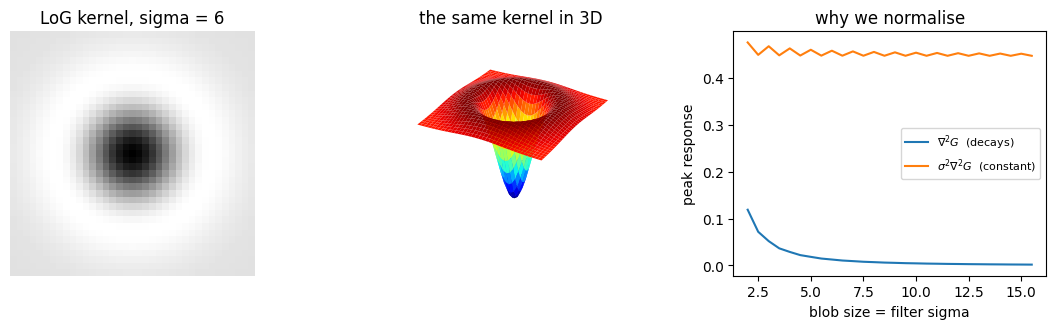

In [2]:
def log_kernel(sigma, ksize=None, scale_normalised=True):
    '''Laplacian of Gaussian kernel.  grad^2 G_sigma, optionally multiplied by sigma^2.'''
    if ksize is None:
        ksize = int(6 * sigma) | 1                    # odd kernel, +-3 sigma of support
    ax = np.arange(ksize) - ksize // 2
    x, y = np.meshgrid(ax, ax)
    r2 = x ** 2 + y ** 2
    k = -1.0 / (np.pi * sigma ** 4) * (1 - r2 / (2 * sigma ** 2)) * np.exp(-r2 / (2 * sigma ** 2))
    return (sigma ** 2 * k if scale_normalised else k).astype(np.float32)


fig = plt.figure(figsize=(11, 3.4))

ax = fig.add_subplot(1, 3, 1)
ax.imshow(log_kernel(6.0)); ax.set_title('LoG kernel, sigma = 6'); ax.axis('off')

ax = fig.add_subplot(1, 3, 2, projection='3d')
k = log_kernel(6.0); ax.plot_surface(*np.meshgrid(np.arange(k.shape[0]), np.arange(k.shape[0])),
                                     k, cmap='jet')
ax.set_title('the same kernel in 3D'); ax.set_axis_off()

# peak response of a matched blob, with and without scale normalisation
ax = fig.add_subplot(1, 3, 3)
N = 200
yy, xx = np.mgrid[0:N, 0:N]
sigmas = np.arange(2, 16, 0.5)
raw, norm = [], []
for s in sigmas:
    b = 1.0 - np.exp(-((xx - N / 2) ** 2 + (yy - N / 2) ** 2) / (2 * s ** 2))   # blob of size s
    raw.append(cv2.filter2D(b, cv2.CV_32F, log_kernel(s, scale_normalised=False))[N // 2, N // 2])
    norm.append(cv2.filter2D(b, cv2.CV_32F, log_kernel(s, scale_normalised=True))[N // 2, N // 2])
ax.plot(sigmas, raw, label=r'$\nabla^2 G$  (decays)')
ax.plot(sigmas, norm, label=r'$\sigma^2 \nabla^2 G$  (constant)')
ax.set_xlabel('blob size = filter sigma'); ax.set_ylabel('peak response')
ax.set_title('why we normalise'); ax.legend(fontsize=8)
plt.tight_layout();

## 2. The Difference of Gaussians approximates the LoG

The Gaussian obeys the heat equation

$$\frac{\partial G}{\partial \sigma} = \sigma\,\nabla^2 G
\qquad\Longrightarrow\qquad
\sigma\,\nabla^2 G \;\approx\; \frac{G_{k\sigma} - G_{\sigma}}{k\sigma - \sigma}$$

so

$$\boxed{\,G_{k\sigma} - G_{\sigma} \;\approx\; (k-1)\,\sigma^2 \nabla^2 G\,}$$

The DoG is therefore an approximation of the **scale-normalised** LoG, up to the constant $(k-1)$ - the same
for every scale, so DoG responses remain comparable across scales.

In practice:

1. blur the image with a $\sigma$ Gaussian,
2. blur the image with a $k\sigma$ Gaussian,
3. subtract.

Two blurs and a subtraction, instead of building and convolving a large LoG kernel at every scale.

> *Sign convention*: the lecture subtracts in the other order ($G_\sigma - G_{k\sigma}$). That only flips the
> sign of the response. We use $G_{k\sigma} - G_{\sigma}$ so the sign matches $\nabla^2_{\mathrm{norm}} G$, and
> in any case we detect **extrema of $|DoG|$**, so the order does not matter.

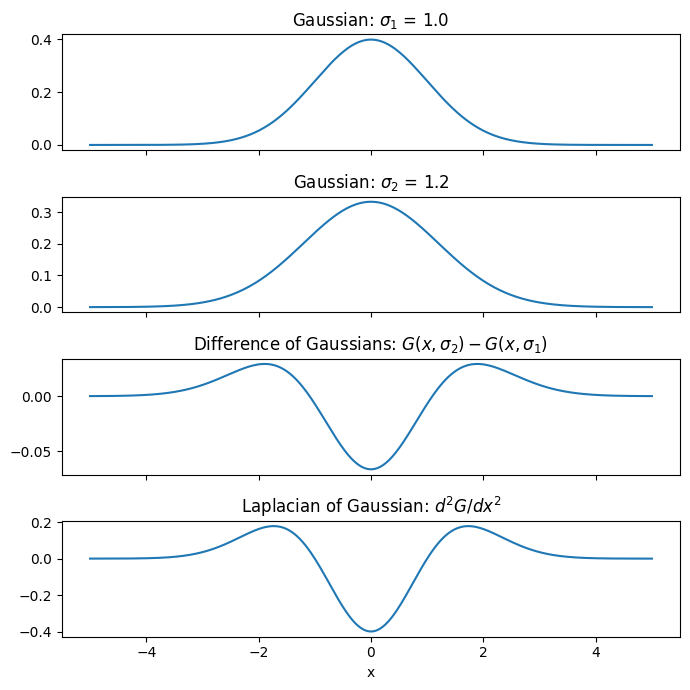

In [3]:
# 1D picture of the approximation
x = np.linspace(-5, 5, 400)
sigma1, k = 1.0, 1.2
sigma2 = k * sigma1

G = lambda x, s: np.exp(-x ** 2 / (2 * s ** 2)) / (s * np.sqrt(2 * np.pi))
d2G = lambda x, s: (x ** 2 - s ** 2) / s ** 4 * G(x, s)          # second derivative of G

fig, ax = plt.subplots(4, 1, figsize=(7, 7), sharex=True)
ax[0].plot(x, G(x, sigma1));                     ax[0].set_title(f'Gaussian: $\\sigma_1$ = {sigma1}')
ax[1].plot(x, G(x, sigma2));                     ax[1].set_title(f'Gaussian: $\\sigma_2$ = {sigma2:.1f}')
ax[2].plot(x, G(x, sigma2) - G(x, sigma1));      ax[2].set_title('Difference of Gaussians: $G(x,\\sigma_2)-G(x,\\sigma_1)$')
ax[3].plot(x, d2G(x, sigma1));                   ax[3].set_title('Laplacian of Gaussian: $d^2G/dx^2$')
ax[3].set_xlabel('x')
plt.tight_layout()

max abs difference between the two kernels: 2.44e-04


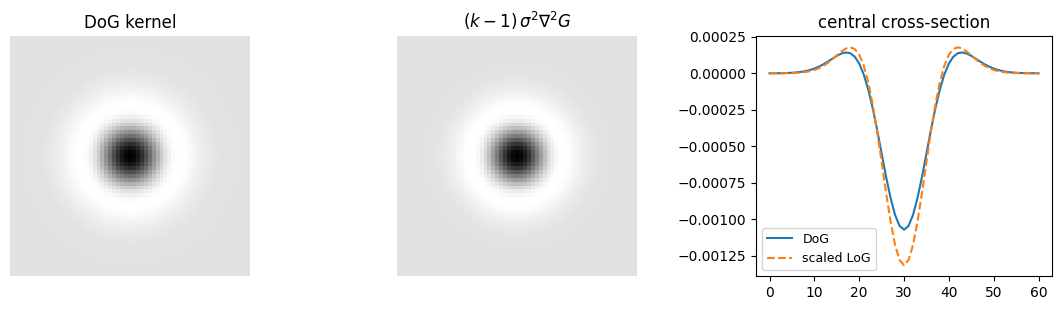

In [4]:
# 2D: the DoG kernel really is a scaled copy of the normalised LoG kernel
sigma, k, ksize = 6.0, 2 ** (1 / 5), 61

g1 = cv2.getGaussianKernel(ksize, sigma)
g2 = cv2.getGaussianKernel(ksize, k * sigma)
dog_k = (g2 @ g2.T) - (g1 @ g1.T)                       # G_ksigma - G_sigma
log_k = (k - 1) * log_kernel(sigma, ksize)              # (k-1) sigma^2 grad^2 G

fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
ax[0].imshow(dog_k); ax[0].set_title('DoG kernel'); ax[0].axis('off')
ax[1].imshow(log_k); ax[1].set_title(r'$(k-1)\,\sigma^2 \nabla^2 G$'); ax[1].axis('off')
ax[2].plot(dog_k[ksize // 2], label='DoG')
ax[2].plot(log_k[ksize // 2], '--', label='scaled LoG')
ax[2].set_title('central cross-section'); ax[2].legend(fontsize=9)
plt.tight_layout()
print('max abs difference between the two kernels: %.2e' % np.abs(dog_k - log_k).max())

## 3. DoG of an image

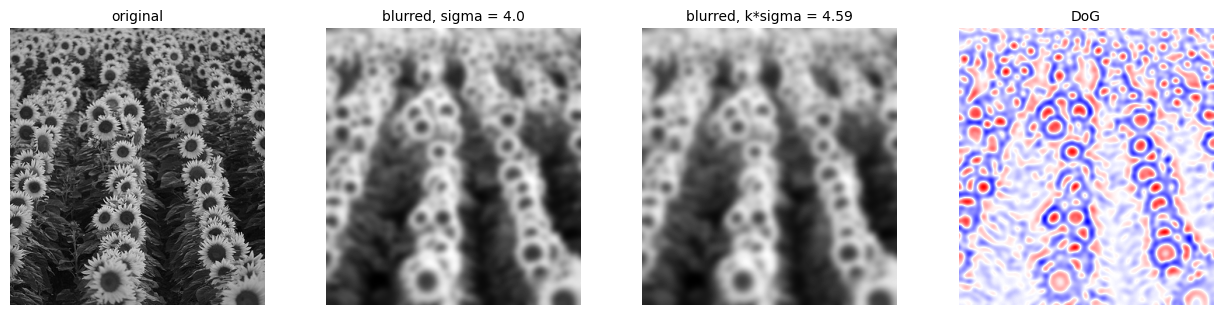

In [5]:
img = cv2.imread('data/images/sunflowers.jpg', cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0

sigma, k = 4.0, 2 ** (1 / 5)
blur1 = gaussian_blur(img, sigma)          # 1. blur with sigma
blur2 = gaussian_blur(img, k * sigma)      # 2. blur with k*sigma
dog = blur2 - blur1                        # 3. subtract

show([img, blur1, blur2, dog],
     ['original', f'blurred, sigma = {sigma}', f'blurred, k*sigma = {k*sigma:.2f}', 'DoG'],
     cmaps=['gray', 'gray', 'gray', 'bwr']);

## 4. Building a DoG scale space

Blur the image with a geometric sequence of scales $\sigma, k\sigma, k^2\sigma, \ldots$ and subtract
neighbouring blurs. With $s$ scales per octave, $k = 2^{1/s}$, so every $s$ layers the blur radius doubles
(one **octave**).

Each DoG layer $D_i = G_{k\sigma_i} * I - G_{\sigma_i} * I$ is assigned the scale $\sigma_i$.

DoG stack: (16, 357, 328)  sigma from 1.00 to 8.00


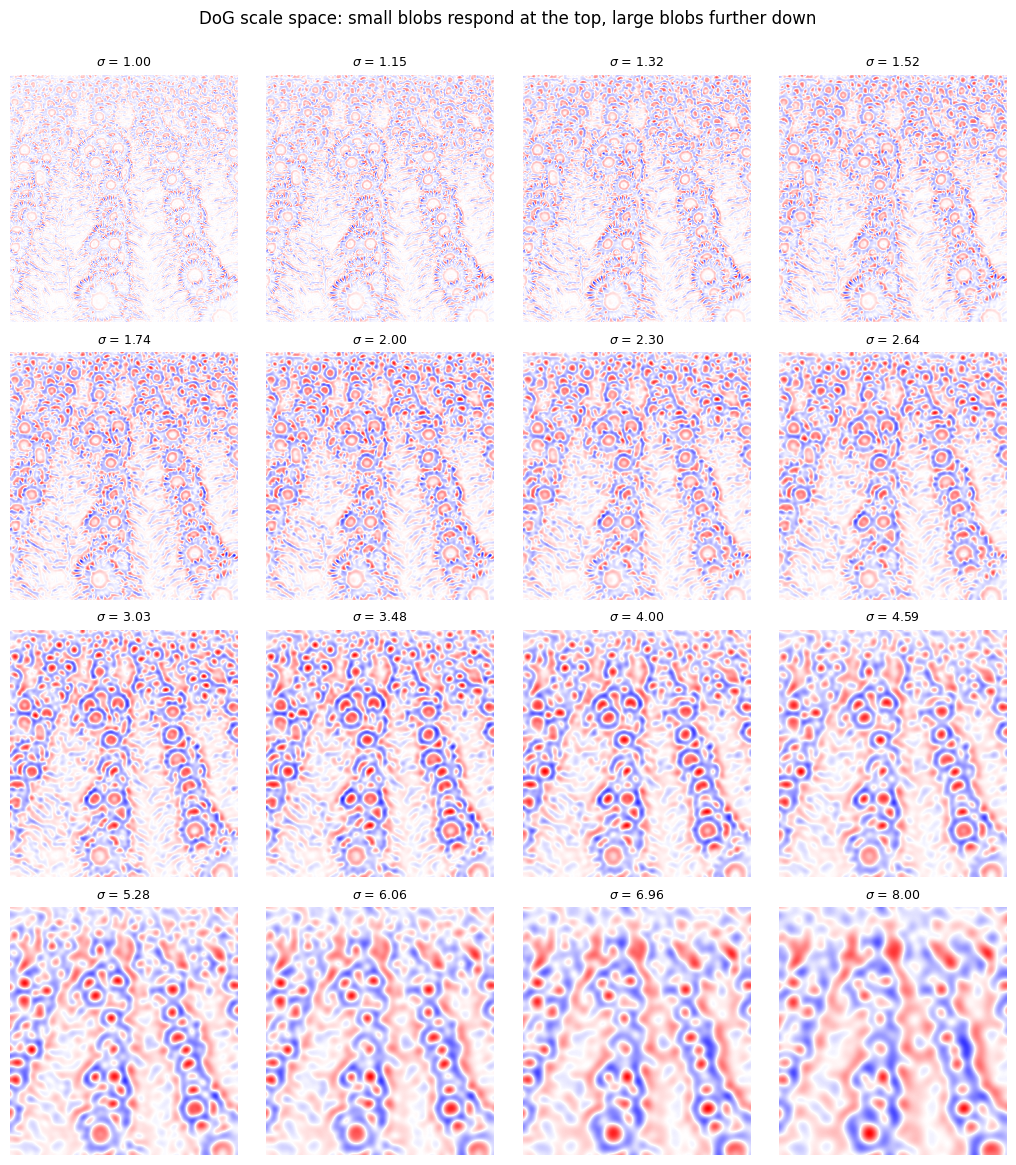

In [6]:
def dog_scale_space(img, sigma0=1.0, scales_per_octave=5, n_octaves=3):
    '''Return (dog, sigmas): a stack of DoG layers and the sigma attached to each layer.'''
    img = img.astype(np.float32)
    if img.max() > 1.0:
        img = img / 255.0
    k = 2 ** (1.0 / scales_per_octave)
    n = scales_per_octave * n_octaves + 1
    sigmas = sigma0 * k ** np.arange(n + 1)
    gauss = [gaussian_blur(img, s) for s in sigmas]
    dog = np.array([gauss[i + 1] - gauss[i] for i in range(n)])   # DoG ~ (k-1) * normalised LoG
    return dog, sigmas[:n]


dog, sigmas = dog_scale_space(img, sigma0=1.0, scales_per_octave=5, n_octaves=3)
print('DoG stack:', dog.shape, ' sigma from %.2f to %.2f' % (sigmas[0], sigmas[-1]))

cols, rows = 4, 4
fig, axes = plt.subplots(rows, cols, figsize=(2.6 * cols, 2.9 * rows))
for i, ax in enumerate(axes.ravel()):
    ax.axis('off')
    if i < len(dog):
        m = np.abs(dog[i]).max()
        ax.imshow(dog[i], cmap='bwr', vmin=-m, vmax=m)
        ax.set_title(f'$\\sigma$ = {sigmas[i]:.2f}', fontsize=9)
plt.suptitle('DoG scale space: small blobs respond at the top, large blobs further down', y=1.0)
plt.tight_layout();

## 5. Characteristic scale

> The **characteristic scale** of an image structure is the scale $\sigma$ at which it produces its
> **strongest DoG response**.

Take one small sunflower and one large one, and follow $|DoG(x, y, \sigma)|$ through the stack at those two
pixels. Each curve has a single clear peak, and the peak sits at a *different* $\sigma$ for the two blobs -
that peak location **is** the size of the blob.

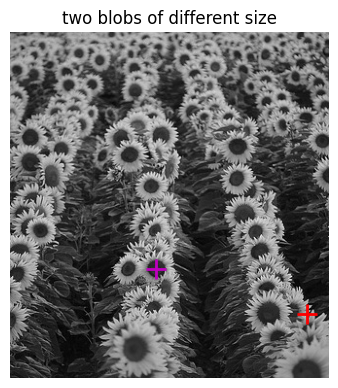

In [7]:
p_small, p_large = (306, 291), (150, 244)          # (x, y)

plt.figure(figsize=(4.5, 4.5))
plt.imshow(img)
plt.plot(*p_small, 'r+', markersize=14, markeredgewidth=2)
plt.plot(*p_large, 'm+', markersize=14, markeredgewidth=2)
plt.title('two blobs of different size'); plt.axis('off');

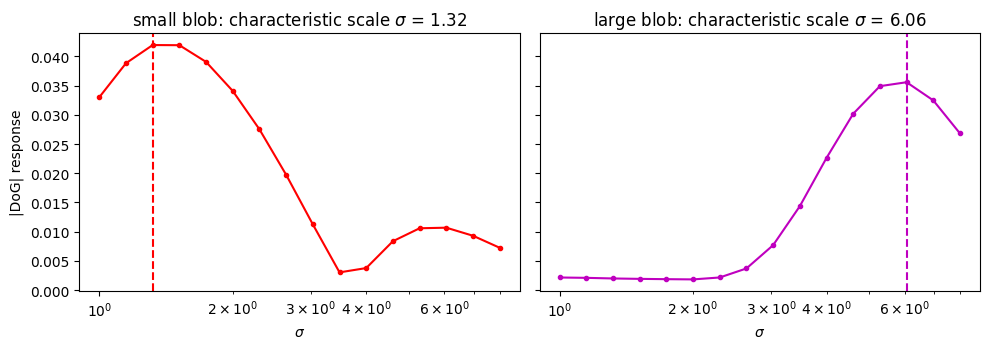

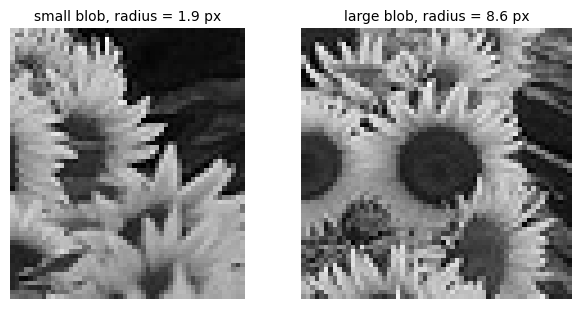

In [8]:
curve_small = np.abs(dog[:, p_small[1], p_small[0]])
curve_large = np.abs(dog[:, p_large[1], p_large[0]])
s_small = sigmas[curve_small.argmax()]
s_large = sigmas[curve_large.argmax()]

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for a, curve, s, c, name in [(ax[0], curve_small, s_small, 'r', 'small blob'),
                             (ax[1], curve_large, s_large, 'm', 'large blob')]:
    a.plot(sigmas, curve, c + '-o', ms=3)
    a.axvline(s, color=c, ls='--')
    a.set_title(f'{name}: characteristic scale $\\sigma$ = {s:.2f}')
    a.set_xlabel(r'$\sigma$'); a.set_xscale('log')
ax[0].set_ylabel('|DoG| response')
plt.tight_layout()

# the region each characteristic scale corresponds to:  radius = sqrt(2) * sigma
show([img[p_small[1] - 30:p_small[1] + 30, p_small[0] - 30:p_small[0] + 30],
      img[p_large[1] - 30:p_large[1] + 30, p_large[0] - 30:p_large[0] + 30]],
     [f'small blob, radius = {np.sqrt(2)*s_small:.1f} px',
      f'large blob, radius = {np.sqrt(2)*s_large:.1f} px']);

## 6. Scale-space non-maximum suppression

A keypoint is a pixel whose $|DoG|$ is larger than all **26 neighbours** - 8 in its own layer and 9 in each of
the layers above and below. For every extremum found, the output is its **location and its scale**:
a list of $(x, y, \sigma)$.

A blob of scale $\sigma$ has its zero-crossings at radius $r = \sqrt{2}\,\sigma$, which is the circle we draw.

In [9]:
def detect_blobs(dog, sigmas, threshold=0.03):
    '''3x3x3 non-maximum suppression on |DoG| -> array of (x, y, sigma).'''
    resp = np.abs(dog)
    is_max = maximum_filter(resp, size=(3, 3, 3)) == resp
    keep = is_max & (resp > threshold)
    keep[0] = keep[-1] = False                        # scales at the ends have no neighbour layer
    s, y, x = np.nonzero(keep)
    return np.column_stack([x, y, sigmas[s]])


def draw_blobs(img, blobs, ax=None, color='r', title=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img, cmap='gray')
    for x, y, s in blobs:
        ax.add_patch(plt.Circle((x, y), np.sqrt(2) * s, color=color, fill=False, lw=1.0))
    ax.set_title(title or f'{len(blobs)} blobs'); ax.axis('off')
    return ax

detected 119 blobs;  sigma range 1.15 - 6.96


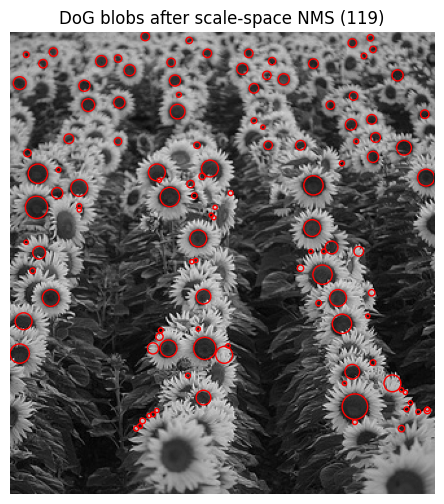

In [10]:
blobs = detect_blobs(dog, sigmas, threshold=0.03)
print('detected', len(blobs), 'blobs;  sigma range %.2f - %.2f' % (blobs[:, 2].min(), blobs[:, 2].max()))
draw_blobs(img, blobs, title=f'DoG blobs after scale-space NMS ({len(blobs)})');

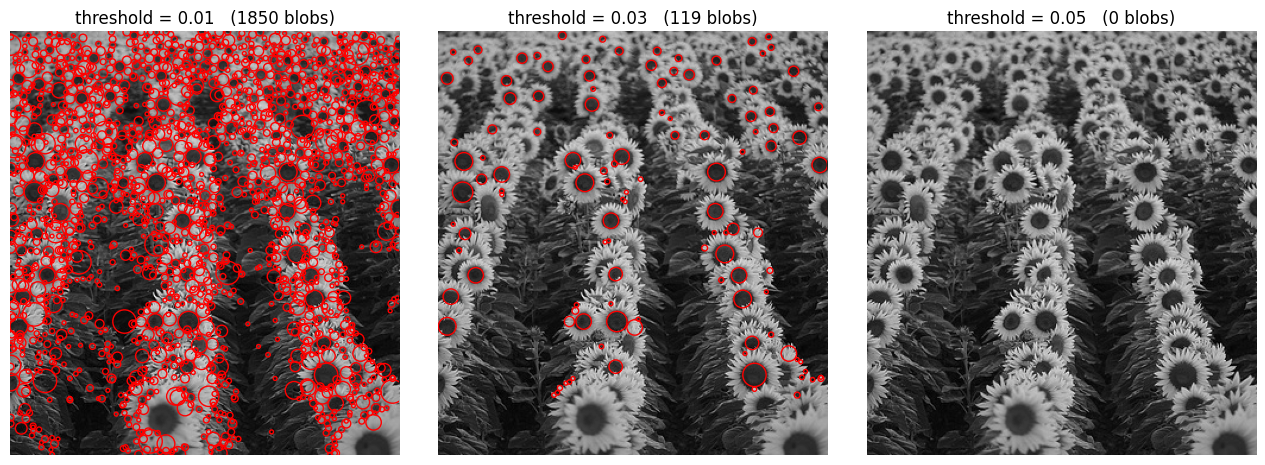

In [11]:
# the threshold trades detections against noise
fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
for ax, t in zip(axes, [0.01, 0.03, 0.05]):
    b = detect_blobs(dog, sigmas, threshold=t)
    draw_blobs(img, b, ax=ax, title=f'threshold = {t}   ({len(b)} blobs)')
plt.tight_layout();

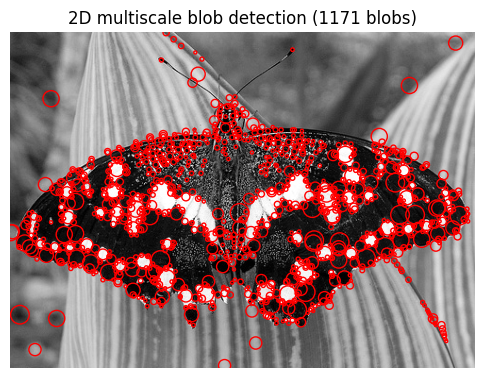

In [12]:
# the butterfly from the lecture slides
butterfly = cv2.imread('data/images/butterfly.jpg', cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
dog_b, sig_b = dog_scale_space(butterfly, sigma0=1.0, scales_per_octave=5, n_octaves=3)
blobs_b = detect_blobs(dog_b, sig_b, threshold=0.02)
draw_blobs(butterfly, blobs_b, title=f'2D multiscale blob detection ({len(blobs_b)} blobs)');

## 7. Is it scale invariant?

Take a crop of the image and **zoom in** on it by 2x. If the detector is scale covariant, the *same*
flowers must come out of both images - but **not at the same $\sigma$**: a structure of size $\sigma$ in the
original has size $2\sigma$ after the zoom.

So we run a **single DoG layer** on each image (no scale search): $\sigma$ on the original, $2\sigma$ on the
zoomed copy.

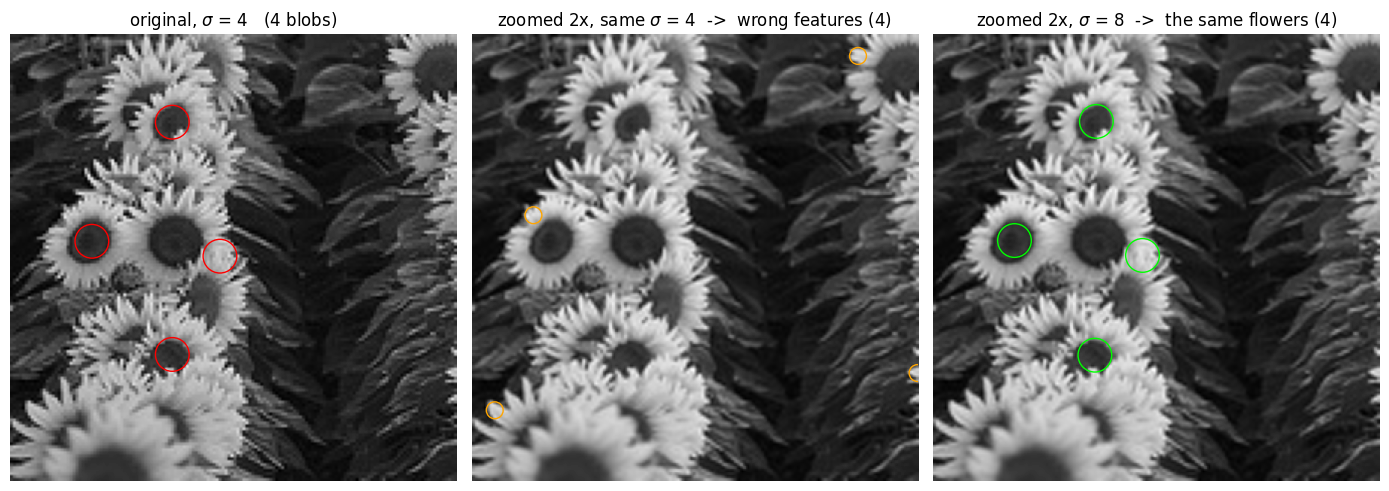

In [13]:
def dog_layer(img, sigma, k=2 ** (1 / 5)):
    '''A single DoG layer: G_ksigma * I  -  G_sigma * I.'''
    return gaussian_blur(img, k * sigma) - gaussian_blur(img, sigma)


def detect_at_one_scale(img, sigma, threshold=0.03, nms_size=5):
    '''2D non-maximum suppression inside one DoG layer -> (x, y, sigma).'''
    resp = np.abs(dog_layer(img, sigma))
    keep = (maximum_filter(resp, size=nms_size) == resp) & (resp > threshold)
    y, x = np.nonzero(keep)
    return np.column_stack([x, y, np.full(len(x), sigma)])


x0, y0, w, h = 95, 175, 150, 150                       # region we zoom into
crop = img[y0:y0 + h, x0:x0 + w]
zoom = cv2.resize(crop, None, fx=2, fy=2, interpolation=cv2.INTER_LINEAR)

sigma_o = 4.0                                          # one scale for the original
sigma_z = 2 * sigma_o                                  # one scale for the zoomed copy

b_orig  = detect_at_one_scale(img,  sigma_o)
b_zoom  = detect_at_one_scale(zoom, sigma_z)
b_wrong = detect_at_one_scale(zoom, sigma_o)           # zoomed image, but the original's scale

# keep only the original's detections that fall inside the zoomed region
inside = ((b_orig[:, 0] > x0 + 10) & (b_orig[:, 0] < x0 + w - 10) &
          (b_orig[:, 1] > y0 + 10) & (b_orig[:, 1] < y0 + h - 10))
b_orig_in = b_orig[inside]

fig, ax = plt.subplots(1, 3, figsize=(14, 5))
draw_blobs(crop, b_orig_in - [x0, y0, 0], ax=ax[0],
           title=f'original, $\\sigma$ = {sigma_o:.0f}   ({len(b_orig_in)} blobs)')
draw_blobs(zoom, b_wrong, ax=ax[1], color='orange',
           title=f'zoomed 2x, same $\\sigma$ = {sigma_o:.0f}  ->  wrong features ({len(b_wrong)})')
draw_blobs(zoom, b_zoom,  ax=ax[2], color='lime',
           title=f'zoomed 2x, $\\sigma$ = {sigma_z:.0f}  ->  the same flowers ({len(b_zoom)})')
plt.tight_layout()

In [14]:
# the same flowers, at twice the position - and with the same response strength
print(f'{"original (sigma = %.0f)" % sigma_o:>26} {"zoomed 2x (sigma = %.0f)" % sigma_z:>26}')
for x, y, s in b_orig_in:
    d = np.hypot(b_zoom[:, 0] - 2 * (x - x0), b_zoom[:, 1] - 2 * (y - y0))
    j = d.argmin()
    print(f'{"(%4.0f,%4.0f)" % (x - x0, y - y0):>26} {"(%4.0f,%4.0f)" % (b_zoom[j, 0], b_zoom[j, 1]):>26}'
          f'      offset from the 2x position: {d[j]:.1f} px')

      original (sigma = 4)      zoomed 2x (sigma = 8)
               (  54,  29)                ( 109,  58)      offset from the 2x position: 1.0 px
               (  27,  69)                (  54, 138)      offset from the 2x position: 0.0 px
               (  70,  74)                ( 140, 148)      offset from the 2x position: 0.0 px
               (  54, 107)                ( 108, 215)      offset from the 2x position: 1.0 px


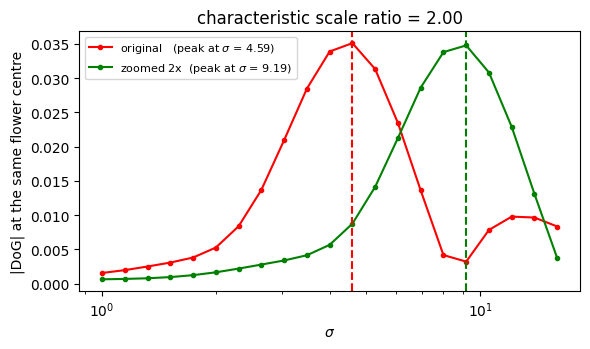

In [15]:
# and the detector is not told the scale: the characteristic scale moves with the zoom
p = (122, 244)                                         # a flower centre, in original coordinates
p_zoom = (2 * (p[0] - x0), 2 * (p[1] - y0))            # the same flower, in zoomed coordinates

sig = 1.0 * 2 ** (np.arange(21) / 5)
curve_o = [abs(dog_layer(img,  s)[p[1], p[0]]) for s in sig]
curve_z = [abs(dog_layer(zoom, s)[p_zoom[1], p_zoom[0]]) for s in sig]
s_o, s_z = sig[int(np.argmax(curve_o))], sig[int(np.argmax(curve_z))]

plt.figure(figsize=(6, 3.6))
plt.plot(sig, curve_o, 'r-o', ms=3, label=f'original   (peak at $\\sigma$ = {s_o:.2f})')
plt.plot(sig, curve_z, 'g-o', ms=3, label=f'zoomed 2x  (peak at $\\sigma$ = {s_z:.2f})')
plt.axvline(s_o, color='r', ls='--'); plt.axvline(s_z, color='g', ls='--')
plt.xscale('log'); plt.xlabel(r'$\sigma$'); plt.ylabel('|DoG| at the same flower centre')
plt.title(f'characteristic scale ratio = {s_z / s_o:.2f}'); plt.legend(fontsize=8)
plt.tight_layout()